#**Data Cleaning**



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df = pd.read_csv('/content/Loan_Prediction_Dataset.csv')

In [ ]:
df

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


###Cleaning Column Names

In [ ]:
df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(' ', '_')
      .str.replace('-', '_')
)
df.columns

Index(['loan_id', 'gender', 'married', 'dependents', 'education',
       'self_employed', 'applicantincome', 'coapplicantincome', 'loanamount',
       'loan_amount_term', 'credit_history', 'property_area', 'loan_status'],
      dtype='object')

In [ ]:
df.rename(columns={"coapplicantincome": "coapplicant_income", "loanamount": "loan_amount", "applicantincome":"applicant_income"}, inplace=True)

###Removing Null Values

In [ ]:
df.isnull().sum()

,0
loan_id,0
gender,13
married,3
dependents,15
education,0
self_employed,32
applicant_income,0
coapplicant_income,0
loan_amount,22
loan_amount_term,14


In [ ]:
#Replaces Null Values with the mode in the 'Gender' column
df['gender'].fillna(df['gender'].mode()[0], inplace=True)

/tmp/ipykernel_646/3579606816.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].fillna(df['gender'].mode()[0], inplace=True)


In [ ]:
#Replaces Null Values with the mode in the 'Married' column
df['married'].fillna(df['married'].mode()[0], inplace=True)

/tmp/ipykernel_646/2030099289.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['married'].fillna(df['married'].mode()[0], inplace=True)


In [ ]:
# Replaces 3+ with 3 in the 'dependents' column
df['dependents'].replace('3+', 3, inplace=True)

# Replaces Null Values with the median in the 'dependents' column
df['dependents'].fillna(df['dependents'].median(), inplace=True)

/tmp/ipykernel_646/159082372.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['dependents'].replace('3+', 3, inplace=True)
/tmp/ipykernel_646/159082372.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using

In [ ]:
#Replaces Null Values with the mode in the 'Self_Employed' column
df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)

/tmp/ipykernel_646/1393851123.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['self_employed'].fillna(df['self_employed'].mode()[0], inplace=True)


In [ ]:
# Replaces Null Values with the median in the 'LoanAmount' column
df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)

/tmp/ipykernel_646/1291828015.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_amount'].fillna(df['loan_amount'].median(), inplace=True)


In [ ]:
# Replaces Null Values with the mode in the 'Credit_History' column
df['credit_history'].fillna(df['credit_history'].mode()[0], inplace=True)

/tmp/ipykernel_646/2919223870.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['credit_history'].fillna(df['credit_history'].mode()[0], inplace=True)


In [ ]:
# Replaces Null Values with the median in the 'Loan_Amount_Term' column
df['loan_amount_term'].fillna(df['loan_amount_term'].median(), inplace=True)

/tmp/ipykernel_646/1828546414.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['loan_amount_term'].fillna(df['loan_amount_term'].median(), inplace=True)


In [ ]:
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0


###Checking for Duplicates

In [ ]:
df.duplicated().sum()

np.int64(0)

###Checking Data Types

In [ ]:
df.dtypes

,0
loan_id,object
gender,object
married,object
dependents,object
education,object
self_employed,object
applicant_income,int64
coapplicant_income,float64
loan_amount,float64
loan_amount_term,float64


In [ ]:
df['dependents'] = df['dependents'].replace('3+', '3')
#Convert 'Dependents' Column into int
df['dependents'] = pd.to_numeric(df['dependents'], errors='coerce').astype('Int64')

In [ ]:
# Convert 'ApplicantIncome' Column into float
df['applicant_income'] = df['applicant_income'].astype('float64')

In [ ]:
# Convert ' Credit_History' Column into int
df['credit_history'] = df['credit_history'].astype('Int64')

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             614 non-null    object 
 1   gender              614 non-null    object 
 2   married             614 non-null    object 
 3   dependents          614 non-null    Int64  
 4   education           614 non-null    object 
 5   self_employed       614 non-null    object 
 6   applicant_income    614 non-null    float64
 7   coapplicant_income  614 non-null    float64
 8   loan_amount         614 non-null    float64
 9   loan_amount_term    614 non-null    float64
 10  credit_history      614 non-null    Int64  
 11  property_area       614 non-null    object 
 12  loan_status         614 non-null    object 
dtypes: Int64(2), float64(4), object(7)
memory usage: 63.7+ KB


In [ ]:
df

,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1,Rural,Y
610,LP002979,Male,Yes,3,Graduate,No,4106.0,0.0,40.0,180.0,1,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1,Urban,Y


#**Exploratory Data Analysis**

##Predict Loan Eligibility for Dream Housing Finance company

Dream Housing Finance Company deals with all kinds of home loans and has a presence across urban, semi-urban, and rural areas. When a customer applies for a home loan, the company first evaluates their eligibility before making a decision. Traditionally, this process could take time and depended heavily on manual review.

The lending industry is a cornerstone of the modern global economy. Financial institutions such as banks and credit unions rely on the interest generated from loans as a major source of revenue. However, lending always involves risk, especially the risk that a borrower may fail to repay the loan. To reduce this risk, institutions carefully assess the creditworthiness of applicants by examining factors such as income, credit history, employment status, and other relevant details.

To improve efficiency and accuracy, Dream Housing Finance Company aims to automate its loan eligibility process in real time. Customers provide information while filling out an online application form, including Gender, Marital Status, Education, Number of Dependents, Income, Loan Amount, Credit History, and other details. Using a dataset of past applications, the company plans to apply machine learning techniques to identify patterns and segment customers who are most likely to be eligible for a loan.

By analyzing historical data, predictive models can estimate the probability of loan approval or default more objectively and quickly than manual evaluation. This transformation not only speeds up the approval process but also minimizes potential losses, optimizes the company’s loan portfolio, and allows the institution to extend credit to a wider range of reliable customers while managing risk effectively.

##Overview

* `Loan_ID` is the unique id of the row and it doesn't have any effect on the target
* `Loan_Status` is the target variable we are trying to predict (Y or N)
    - Y = Loan Approved
    - N = Loan Not Approved
* `Gender` is the gender of the applicant (Male/Female)
* `Married` ndicates the marital status of the applicant (Yes/No)
* `Dependents` represents the total number of the applicants' dependents (0, 1, 2, 3...)
* `Education` indicates the education level (Graduate/Not Graduate)
* `Self_Employed` indicates whether the applicant is self-employed (Yes/No)
* `ApplicantIncome` is the primary applicant's income
* `CoapplicantIncome` is the co-applicant's income
* `LoanAmount` is the requested loan amount in thousands
* `Loan_Amount_Term` is the term of the loan in months
* `Credit_History` indicates if credit history meets guidelines (1 or 0)
* `Property_Area` is the area type of the property (Urban/Semiurban/Rural)

In [ ]:
df.head()

,loan_id,gender,married,dependents,education,self_employed,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,property_area,loan_status
0,LP001002,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1,Urban,Y


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   loan_id             614 non-null    object 
 1   gender              614 non-null    object 
 2   married             614 non-null    object 
 3   dependents          614 non-null    Int64  
 4   education           614 non-null    object 
 5   self_employed       614 non-null    object 
 6   applicant_income    614 non-null    float64
 7   coapplicant_income  614 non-null    float64
 8   loan_amount         614 non-null    float64
 9   loan_amount_term    614 non-null    float64
 10  credit_history      614 non-null    Int64  
 11  property_area       614 non-null    object 
 12  loan_status         614 non-null    object 
dtypes: Int64(2), float64(4), object(7)
memory usage: 63.7+ KB


In [ ]:
df.describe()

,dependents,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history
count,614.0,614.000000,614.000000,614.000000,614.000000,614.0
mean,0.7443,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,1.009623,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,0.0,150.000000,0.000000,9.000000,12.000000,0.0
25%,0.0,2877.500000,0.000000,100.250000,360.000000,1.0
50%,0.0,3812.500000,1188.500000,128.000000,360.000000,1.0
75%,1.0,5795.000000,2297.250000,164.750000,360.000000,1.0
max,3.0,81000.000000,41667.000000,700.000000,480.000000,1.0


In [ ]:
df.isnull().sum()

,0
loan_id,0
gender,0
married,0
dependents,0
education,0
self_employed,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0


##Univariate Analysis

###Gender

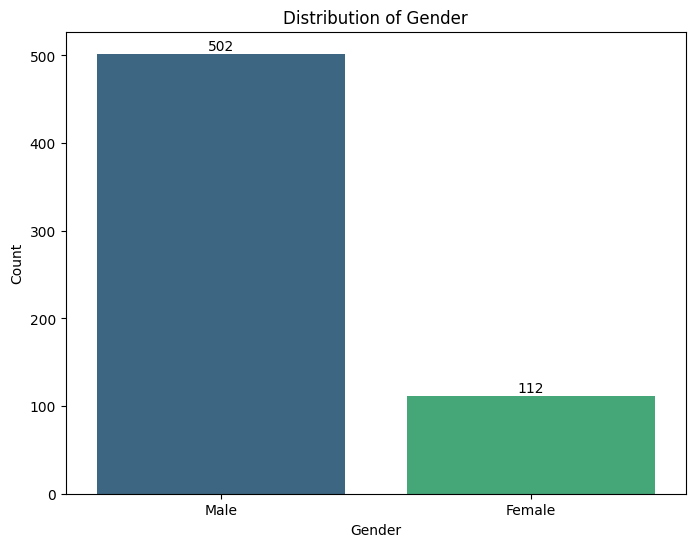

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='gender', hue='gender', palette='viridis', legend=False)
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the gender distribution within a specific dataset. It was generated using Python’s Seaborn and Matplotlib libraries to provide a clear visual count of the "Male" and "Female" categories.

The chart reveals a significant disparity between the two groups:

Male: 502 individuals.

Female: 112 individuals.

Total Count: 614 individuals.

The dataset is heavily skewed, with the number of males being approximately 4.5 times higher than the number of females. The "Male" bar (dark blue) occupies the vast majority of the sample, while the "Female" bar (green) represents a much smaller subset.



###Married

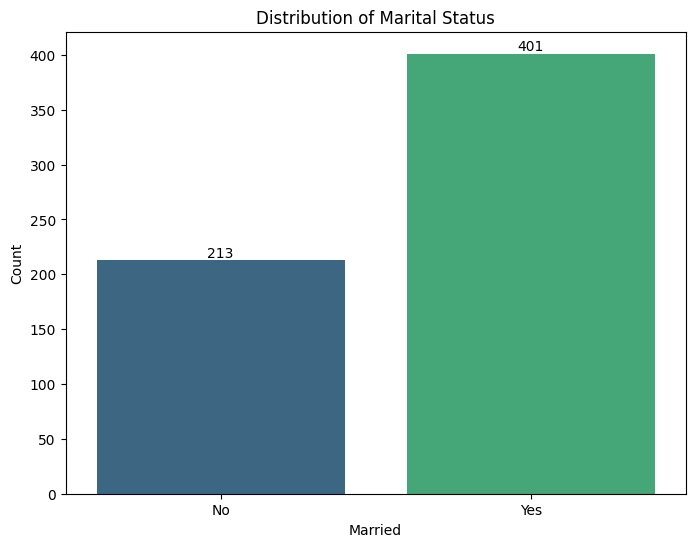

In [ ]:

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='married', hue='married', palette='viridis', legend=False)
plt.title('Distribution of Marital Status')
plt.xlabel('Married')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the distribution of marital status within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries to provide a clear visual count of the "No" and "Yes" categories.

The chart reveals a notable difference between the two groups:

Yes (Married): 401 individuals.

No (Not Married): 213 individuals.

Total Count: 614 individuals.

The dataset shows that the majority of the sample consists of married individuals. The "Yes" bar (green) represents approximately 65% of the total, while the "No" bar (dark blue) represents the remaining 35%.

###Dependents

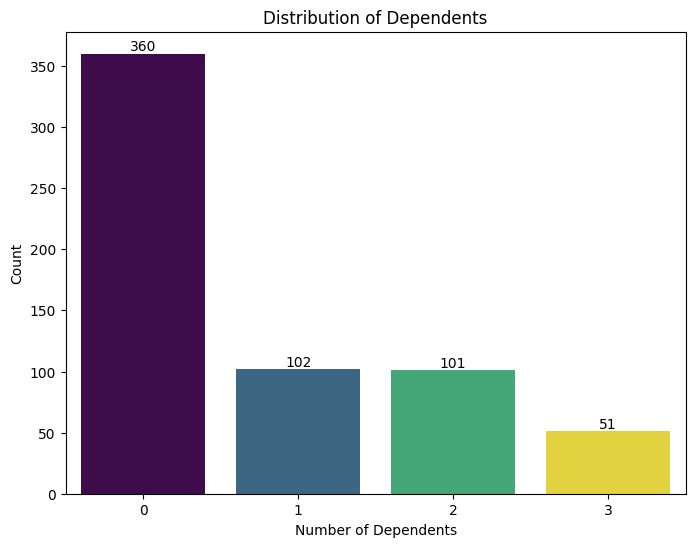

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='dependents', hue='dependents', palette='viridis', legend=False)
plt.title('Distribution of Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the Distribution of Dependents within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries, utilizing a "viridis" color palette and data annotations to display exact counts for each category.

The chart breaks down the number of dependents as follows:

0 Dependents: 360 individuals (The clear majority)

1 Dependent: 102 individuals

2 Dependents: 101 individuals

3 Dependents: 51 individuals

Total Count: 614 individuals

The data shows a significant skew toward individuals with no dependents, who make up approximately 58.6% of the total sample. As the number of dependents increases, the frequency in the dataset steadily decreases.

###Education

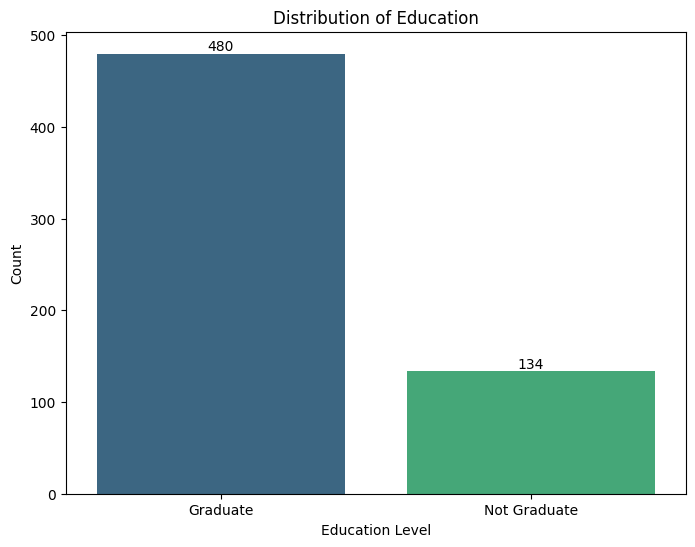

In [ ]:

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='education', hue='education', palette='viridis', legend=False)
plt.title('Distribution of Education')
plt.xlabel('Education Level')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()


This bar chart illustrates the Distribution of Education within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries to provide a visual breakdown of educational attainment levels.

The chart reveals a significant disparity between the two categories:

Graduate: 480 individuals.

Not Graduate: 134 individuals.

Total Count: 614 individuals.

The dataset is predominantly composed of graduates, who represent approximately 78% of the total sample. The "Graduate" bar (blue) is more than three times the size of the "Not Graduate" bar (green), which accounts for the remaining 22%.

###Self Employed

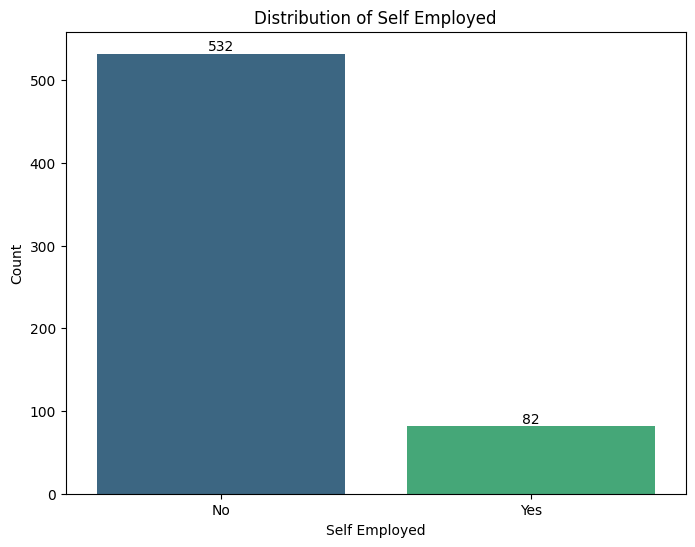

In [ ]:

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='self_employed', hue='self_employed', palette='viridis', legend=False)
plt.title('Distribution of Self Employed')
plt.xlabel('Self Employed')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the Distribution of Self-Employed status within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries to provide a visual count of the "No" and "Yes" categories.

The chart reveals a stark contrast between the two groups:

No (Not Self-Employed): 532 individuals.

Yes (Self-Employed): 82 individuals.

Total Count: 614 individuals.

The data shows that the vast majority of the sample consists of individuals who are not self-employed. The "No" bar (dark blue) represents approximately 86.6% of the total, while the "Yes" bar (green) accounts for only about 13.4%.

###Applicant Income

/tmp/ipykernel_646/4243767520.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data=df, x='applicant_income', bins=20, kde=True, palette='viridis')


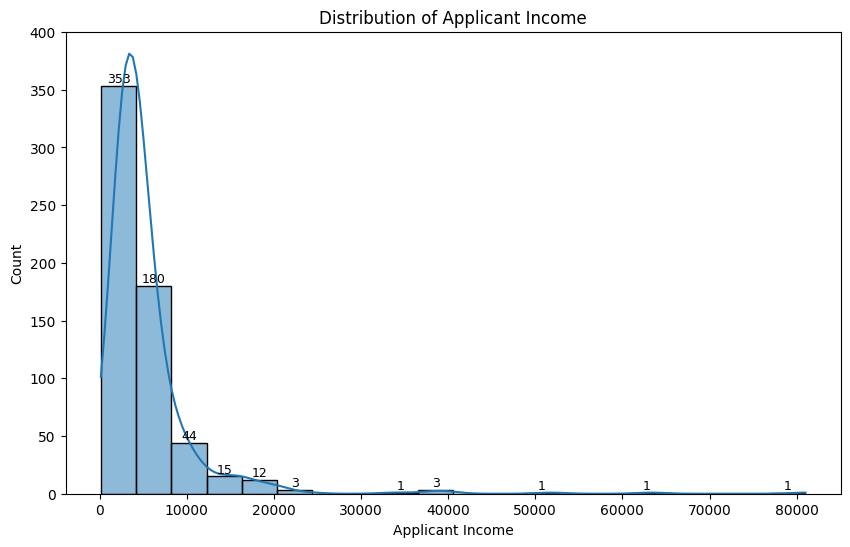

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='applicant_income', bins=20, kde=True, palette='viridis')
plt.title('Distribution of Applicant Income')
plt.xlabel('Applicant Income')
plt.ylabel('Count')

for p in ax.patches:
    if p.get_height() > 0: # Only annotate non-zero height bars
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()


This histogram illustrates the Distribution of Applicant Income within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries, featuring a Kernel Density Estimate (KDE) line to show the shape of the data distribution.

The chart reveals a heavily right-skewed distribution of income:

Low Income Range (0–10,000): This is the most dense area, with the vast majority of applicants falling here (353 individuals in the lowest bin and 180 in the second).

Middle Income Range (10,000–20,000): A significantly smaller group, totaling roughly 56 individuals across these bins.

High Income Outliers (20,000+): Only a few individuals represent very high incomes, with rare instances reaching up to 80,000.

Total Count: 614 individuals.

The dataset shows that most applicants are concentrated in the lower income brackets, with approximately 86.8% of the sample earning less than 10,000. The long "tail" to the right indicates that while some applicants earn significantly more, they are extreme outliers compared to the general population.

###Coaplicant Income

/tmp/ipykernel_646/3281166069.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data=df, x='coapplicant_income', bins=20, kde=True, palette='viridis')


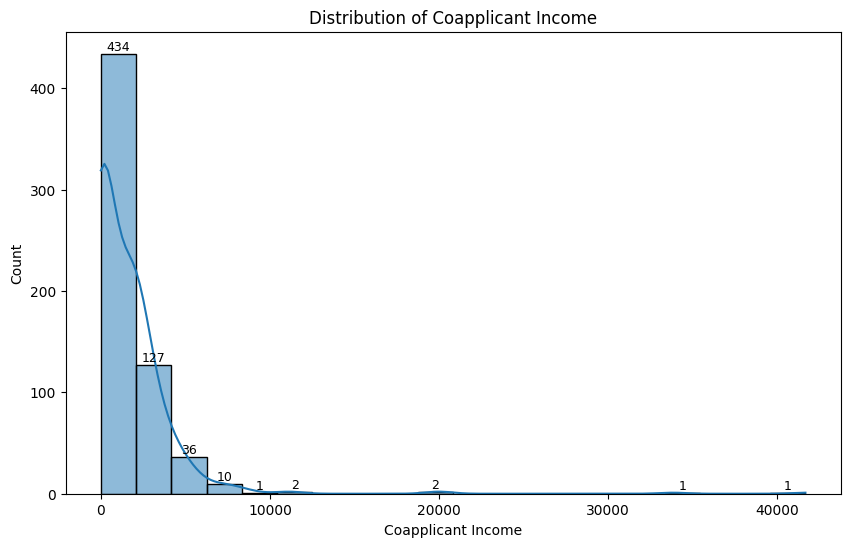

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='coapplicant_income', bins=20, kde=True, palette='viridis')
plt.title('Distribution of Coapplicant Income')
plt.xlabel('Coapplicant Income')
plt.ylabel('Count')

for p in ax.patches:
    if p.get_height() > 0: # Only annotate non-zero height bars
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()


This histogram illustrates the Distribution of Coapplicant Income within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries, including a Kernel Density Estimate (KDE) line to visualize the probability density of the income levels.

The chart reveals a distribution that is even more heavily right-skewed than the primary applicant income:

Low Income/Zero Range (0–5,000): The vast majority of coapplicants fall into this bracket, with 434 individuals in the first bin alone.

Moderate Income Range (5,000–10,000): A sharp decline is visible, with only about 46 individuals scattered across these bins.

High Income Outliers (10,000+): Very few coapplicants have incomes in this range, with rare outliers extending up to 40,000.

Total Count: 614 individuals.

The data indicates that most coapplicants have either very low income or perhaps no income at all, with approximately 70.7% of the sample falling into the lowest bin. This extreme skew suggests that coapplicant income may not be a primary factor for a large portion of the dataset.

###Loan Amount

/tmp/ipykernel_646/853303045.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax = sns.histplot(data=df, x='loan_amount', bins=20, kde=True, palette='viridis')


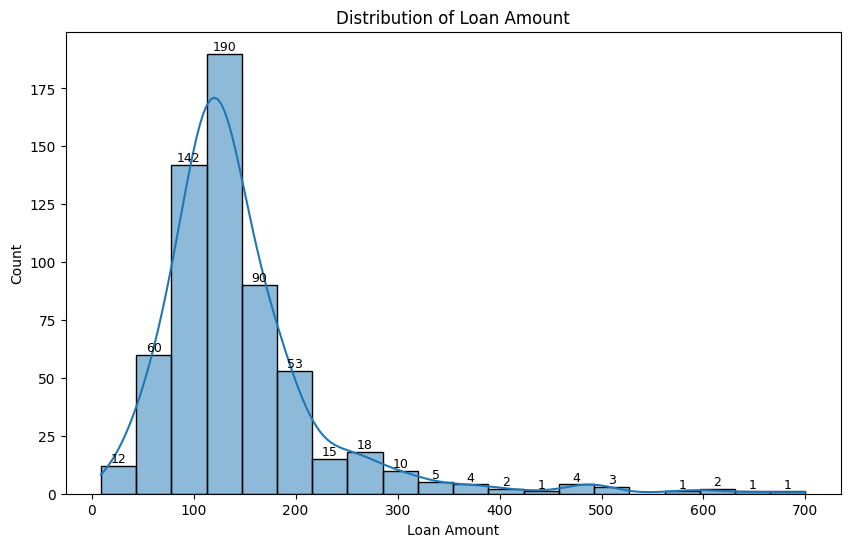

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.histplot(data=df, x='loan_amount', bins=20, kde=True, palette='viridis')
plt.title('Distribution of Loan Amount')
plt.xlabel('Loan Amount')
plt.ylabel('Count')

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', xytext=(0, 5),
                    textcoords='offset points')

plt.show()

This histogram illustrates the Distribution of Loan Amount within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries, including a Kernel Density Estimate (KDE) line to represent the probability density of the requested loan sizes.

The chart reveals a moderately right-skewed distribution centered around mid-range values:

Most Common Range (100–200): This is the peak of the dataset, with 190 individuals in the 100–150 bracket and 90 in the 150–200 bracket.

Low Loan Amounts (0–100): A smaller group of roughly 214 individuals requested loans under 100.

High Loan Amounts/Outliers (300+): The frequency drops significantly for loans over 300, though extreme outliers exist up to 700.

Total Count: 614 individuals.

The data indicates that the majority of applicants (approximately 45%) are seeking loans between 100 and 200 units. While the distribution is more balanced than the income charts, the presence of a long right tail suggests that a few applicants are requesting exceptionally large loan amounts compared to the rest of the group.

###Loan Amount Term

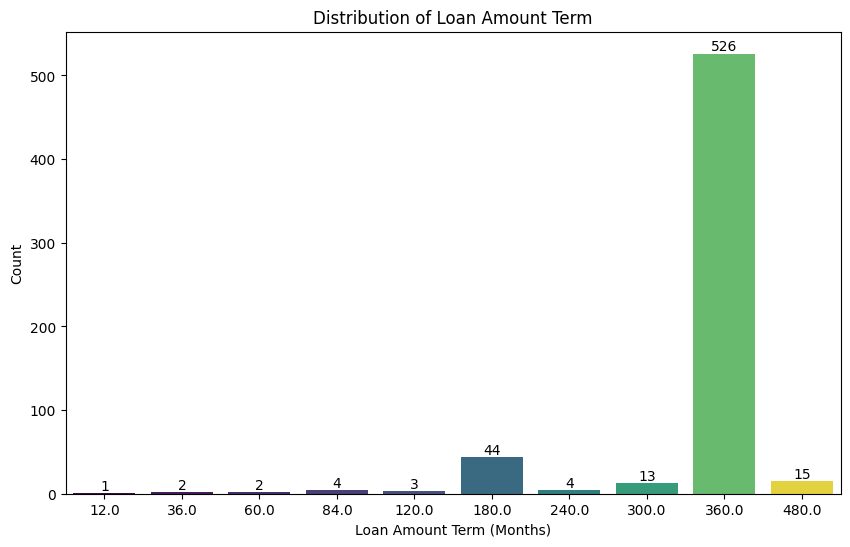

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='loan_amount_term', hue='loan_amount_term', palette='viridis', legend=False)
plt.title('Distribution of Loan Amount Term')
plt.xlabel('Loan Amount Term (Months)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the Distribution of Loan Amount Term (in months) within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries with the "viridis" palette and exact data labels.

The chart shows a massive concentration in one specific category:

360 Months (30 Years): 526 individuals.

180 Months (15 Years): 44 individuals.

Other Terms: A small mix of terms (ranging from 12 to 480 months) accounting for the remaining 44 individuals.

Total Count: 614 individuals.

The dataset is overwhelmingly dominated by the 360-month term, which represents approximately 85.7% of all loans. This indicates that the vast majority of applicants are seeking long-term, 30-year financing, while other durations like the 15-year term (180 months) are far less common.

###Credit History

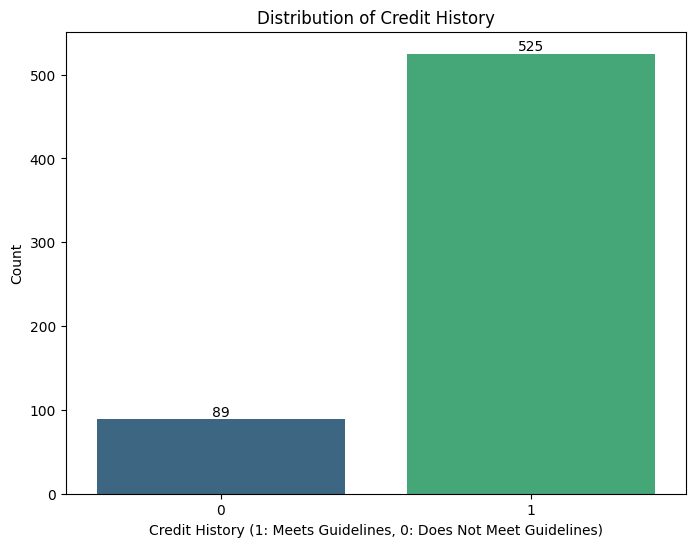

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='credit_history', hue='credit_history', palette='viridis', legend=False)
plt.title('Distribution of Credit History')
plt.xlabel('Credit History (1: Meets Guidelines, 0: Does Not Meet Guidelines)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()


This bar chart illustrates the Distribution of Credit History within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries to provide a visual count of applicants who meet credit guidelines versus those who do not.

The chart reveals a significant majority of applicants with a positive credit history:

1 (Meets Guidelines): 525 individuals.

0 (Does Not Meet Guidelines): 89 individuals.

Total Count: 614 individuals.

The data indicates that the vast majority of the sample—approximately 85.5%—possesses a credit history that meets the required guidelines. This suggests that the dataset is heavily skewed toward creditworthy applicants, with the "1" bar (green) being nearly six times larger than the "0" bar (dark blue).



###Property Area

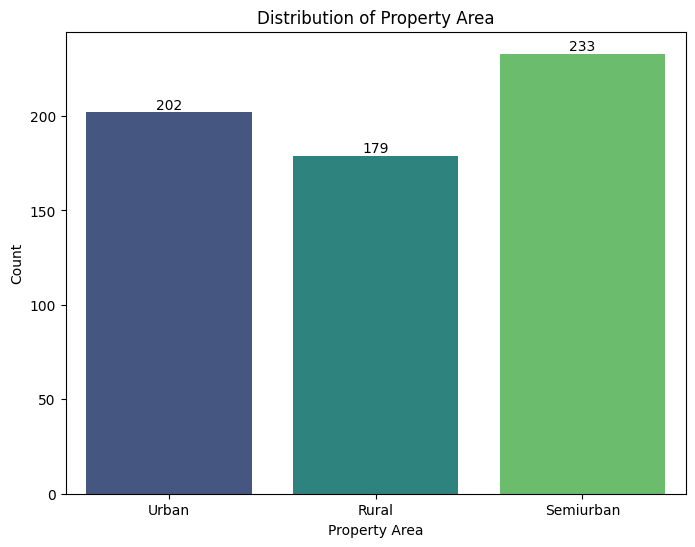

In [ ]:

plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='property_area', hue='property_area', palette='viridis', legend=False)
plt.title('Distribution of Property Area')
plt.xlabel('Property Area')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the Distribution of Property Area within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries, using the "viridis" palette to categorize and count the different types of residential locations.

The chart shows a relatively balanced distribution across three main areas:

Semiurban: 233 individuals.

Urban: 202 individuals.

Rural: 179 individuals.

Total Count: 614 individuals.

The data reveals that Semiurban properties are the most common in this dataset, representing approximately 38% of the total. Urban areas follow at roughly 33%, while Rural areas make up the smallest portion at about 29%. Unlike previous charts where one category dominated, the distribution here is more even across all property types.

###Loan Status

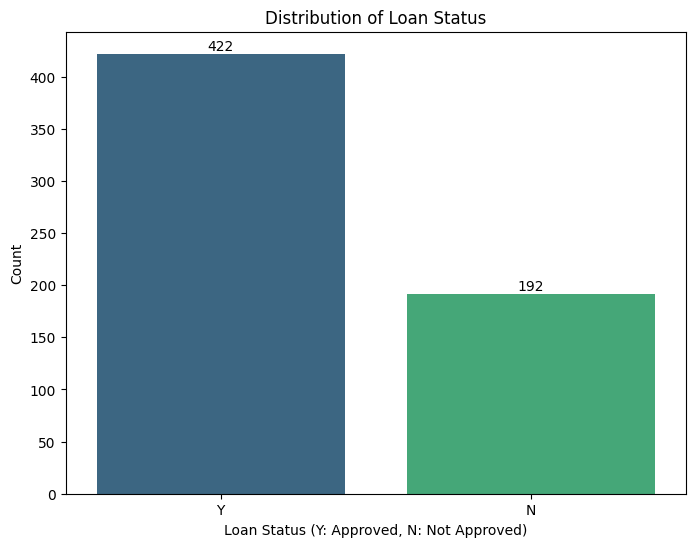

In [ ]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=df, x='loan_status', hue='loan_status', palette='viridis', legend=False)
plt.title('Distribution of Loan Status')
plt.xlabel('Loan Status (Y: Approved, N: Not Approved)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

This bar chart illustrates the Distribution of Loan Status within the dataset. It was generated using Python’s Seaborn and Matplotlib libraries to visualize the final outcome of loan applications.

The chart reveals a clear distinction between approved and not approved loans:

Y (Approved): 422 individuals.

N (Not Approved): 192 individuals.

Total Count: 614 individuals.

The dataset shows a high success rate for applicants, with approximately 68.7% of loans being approved. The "Y" bar (dark blue) is more than twice as large as the "N" bar (green), which represents the remaining 31.3% of the sample.

##Bivariate Analysis

###Gender and Loan Status

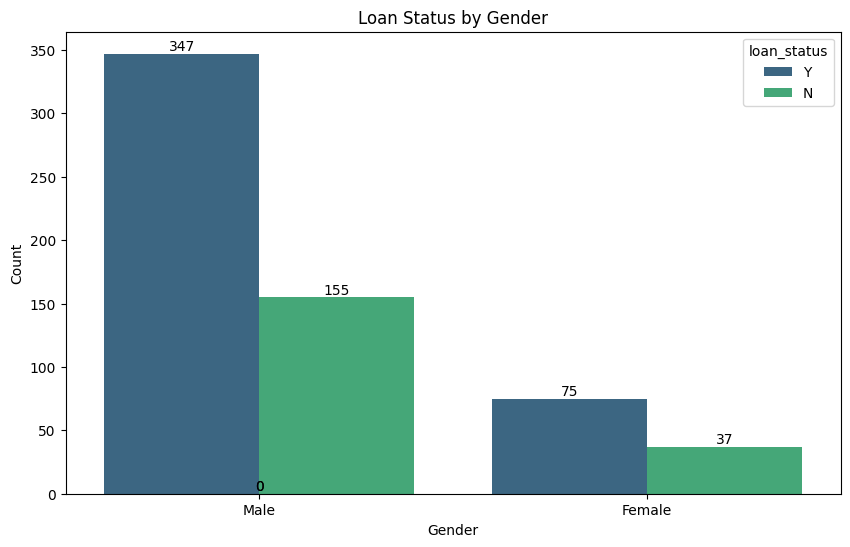

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='gender', hue='loan_status', palette='viridis')
plt.title('Loan Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

###Married and Loan Statsus

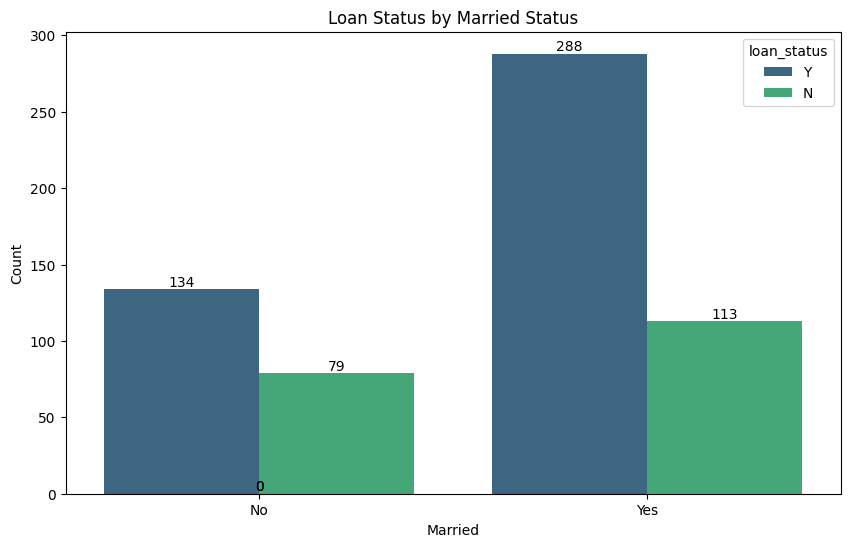

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='married', hue='loan_status', palette='viridis')
plt.title('Loan Status by Married Status')
plt.xlabel('Married')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

###Dependents and Loan Status

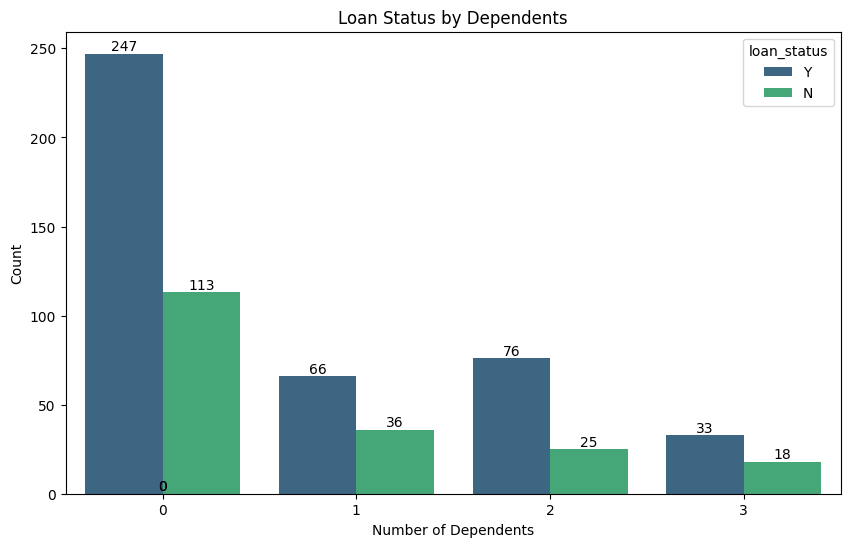

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='dependents', hue='loan_status', palette='viridis')
plt.title('Loan Status by Dependents')
plt.xlabel('Number of Dependents')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

###Education vs Loan Status

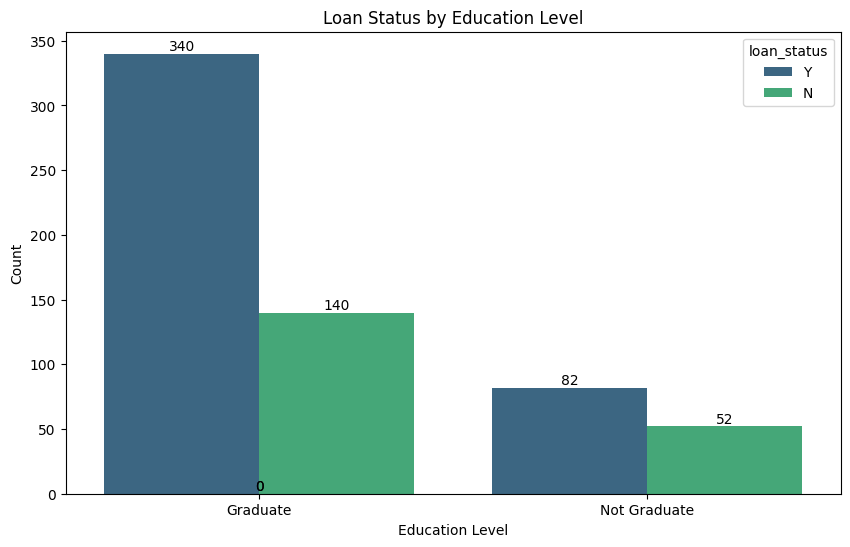

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='education', hue='loan_status', palette='viridis')
plt.title('Loan Status by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

###Applicant Income and Loan Status

/tmp/ipykernel_646/810509988.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='loan_status', y='applicant_income', palette='viridis')
/tmp/ipykernel_646/810509988.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Approved', 'Not Approved'])


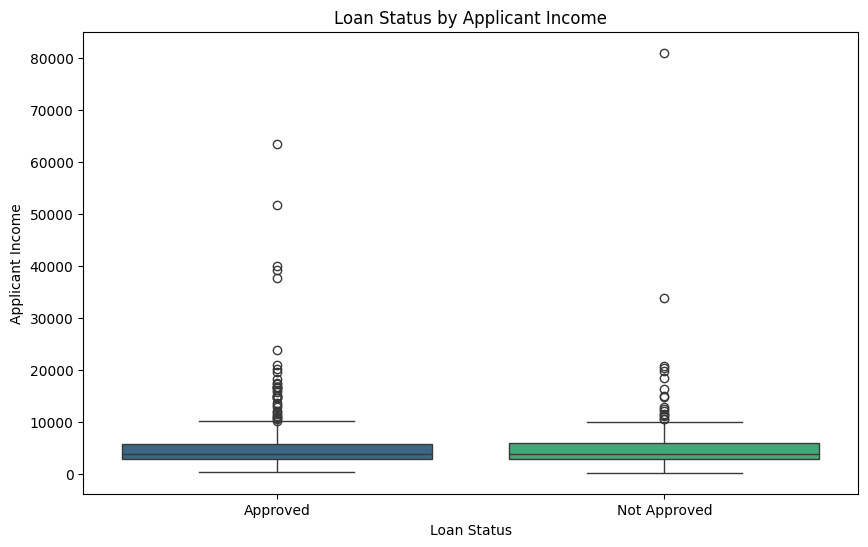

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='loan_status', y='applicant_income', palette='viridis')
ax.set_xticklabels(['Approved', 'Not Approved'])
plt.title('Loan Status by Applicant Income')
plt.xlabel('Loan Status')
plt.ylabel('Applicant Income')
plt.show()

###Self Employed and Loan Status

/tmp/ipykernel_646/2625642598.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_x_labels)


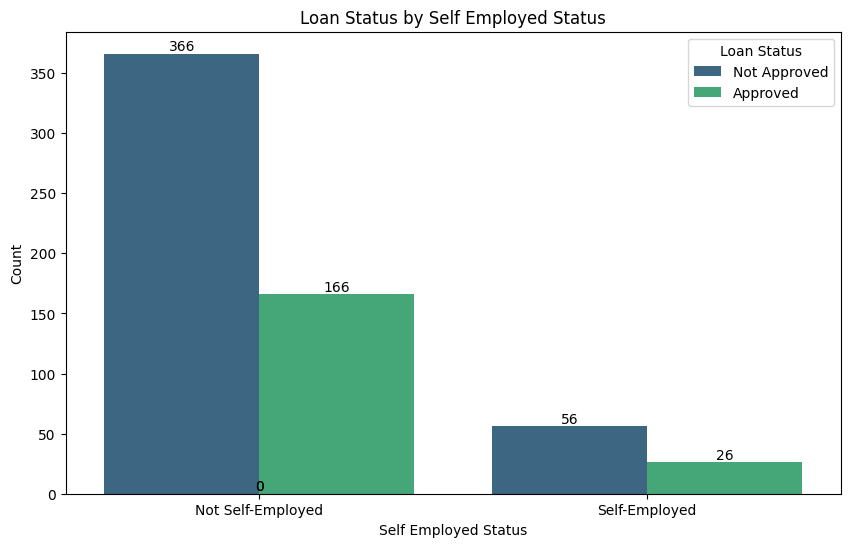

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='self_employed', hue='loan_status', palette='viridis')
plt.title('Loan Status by Self Employed Status')
plt.xlabel('Self Employed Status')

new_x_labels = ['Not Self-Employed', 'Self-Employed']
ax.set_xticklabels(new_x_labels)


handles, labels = ax.get_legend_handles_labels()
new_legend_labels = ['Not Approved', 'Approved']
ax.legend(handles=handles, labels=new_legend_labels, title='Loan Status') # Add a legend title for clarity

plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

###Coapplicant Income and Loan Status

/tmp/ipykernel_646/1752472096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='loan_status', y='coapplicant_income', palette='viridis')


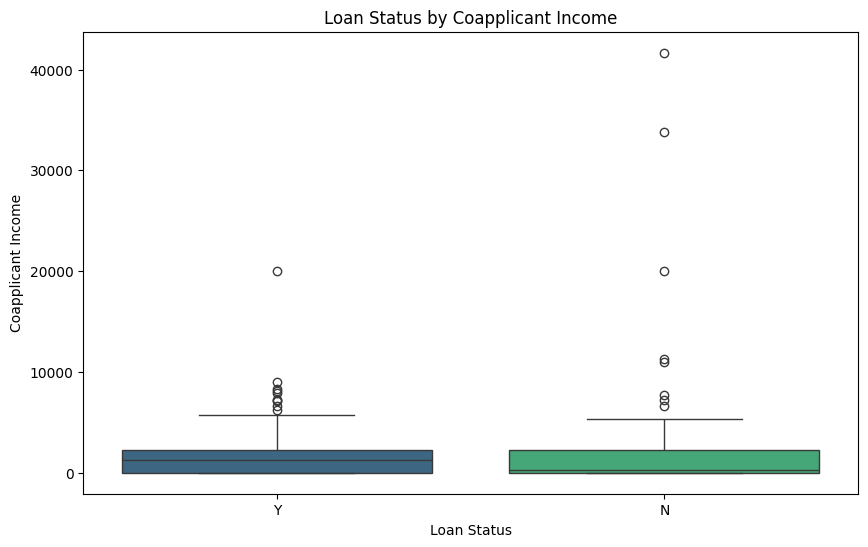

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='loan_status', y='coapplicant_income', palette='viridis')
plt.title('Loan Status by Coapplicant Income')
plt.xlabel('Loan Status')
plt.ylabel('Coapplicant Income')
plt.show()

###Loan Amount and Loan Status

/tmp/ipykernel_646/1492900072.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df, x='loan_status', y='loan_amount', palette='viridis')


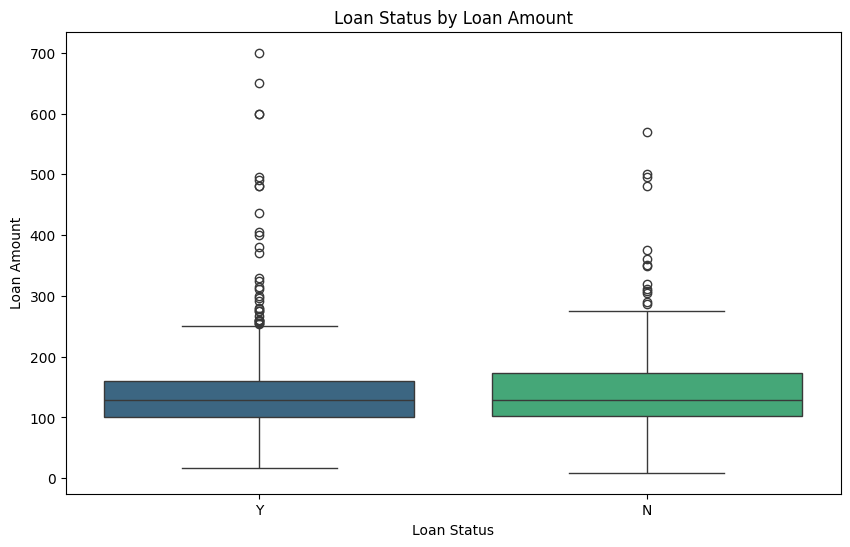

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df, x='loan_status', y='loan_amount', palette='viridis')
plt.title('Loan Status by Loan Amount')
plt.xlabel('Loan Status')
plt.ylabel('Loan Amount')
plt.show()

###Credit History and Loan Status

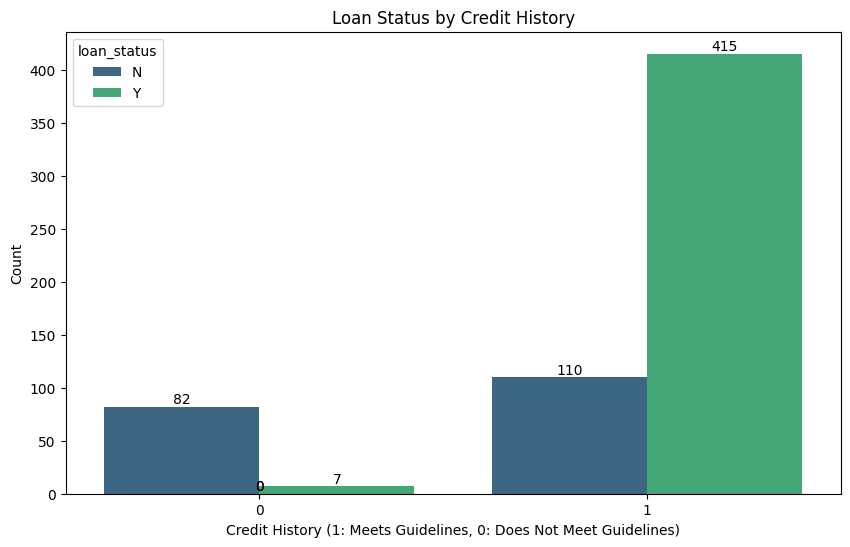

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='credit_history', hue='loan_status', palette='viridis')
plt.title('Loan Status by Credit History')
plt.xlabel('Credit History (1: Meets Guidelines, 0: Does Not Meet Guidelines)')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

### Property Area and Loan Status

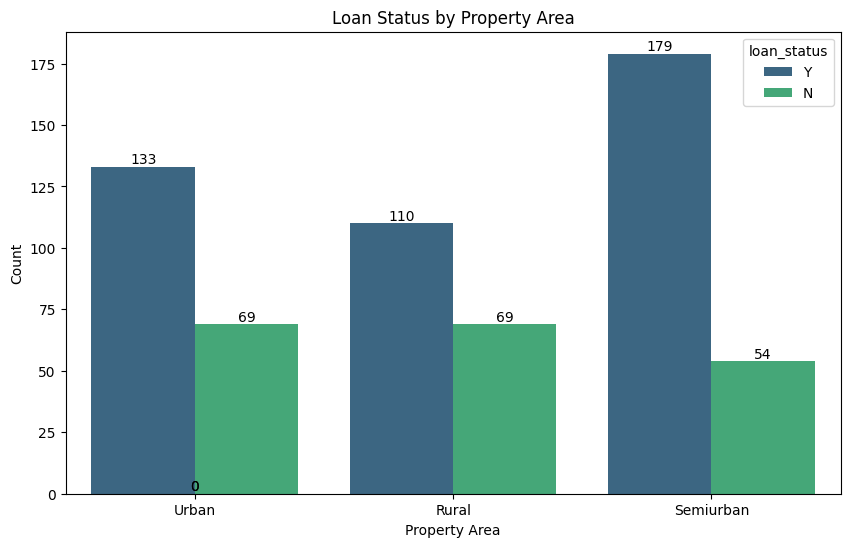

In [ ]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='property_area', hue='loan_status', palette='viridis')
plt.title('Loan Status by Property Area')
plt.xlabel('Property Area')
plt.ylabel('Count')

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=10, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

##Multivariate Analysis

###Applicant Income, Coapplicant Income, Credit History, Loan Amount, Loan Amount Term and Loan Status

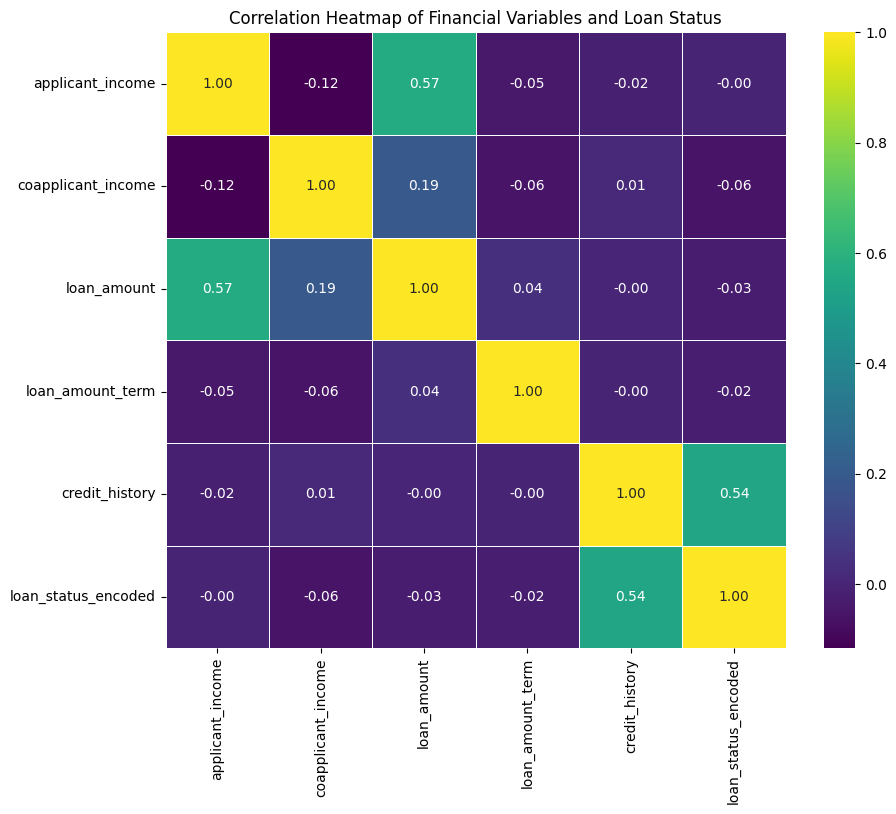

In [ ]:
# Encode 'loan_status' to numerical values (Y=1, N=0)
df['loan_status_encoded'] = df['loan_status'].map({'Y': 1, 'N': 0})

# Select the relevant columns for the heatmap
selected_columns = [
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'loan_amount_term',
    'credit_history',
    'loan_status_encoded'
]

# Calculate the correlation matrix
correlation_matrix = df[selected_columns].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='viridis',
    fmt=".2f",
    linewidths=.5
)
plt.title('Correlation Heatmap of Financial Variables and Loan Status')
plt.show()

#**Data Preprocessing**

###Data Encoding

In [ ]:
#Additional Combined income column
df['total_income'] = df['applicant_income'] + df['coapplicant_income']


In [ ]:
#Encoded load status in EDA for heatmap

#One Hot-Encoding
df = pd.get_dummies(df, columns=['married', 'education', 'self_employed', 'property_area'], drop_first=True)



In [ ]:
#Applying Logmarithmic Transformation
#This helps the model learn better and avoid being overly influenced by extreme values

df['applicant_income'] = np.log1p(df['applicant_income'])
df['coapplicant_income'] = np.log1p(df['coapplicant_income'])
df['total_income'] = np.log1p(df['total_income'])
df['loan_amount'] = np.log1p(df['loan_amount'])

In [ ]:
from sklearn.preprocessing import StandardScaler

#Standardizes the scale to ensure data is in the best possible shape for machine learning

# Identify numerical columns to scale
numerical_cols = [
    'dependents',
    'applicant_income',
    'coapplicant_income',
    'loan_amount',
    'loan_amount_term',
    'credit_history'
]

# Instantiate StandardScaler
scaler = StandardScaler()

# Apply scaling to the numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])


1. **Cleaning Column Names & Data Types**: Ensures data is consistent and can be correctly interpreted by tools and models.
2. **Handling Missing Values**: Prevents errors and biases that could arise from incomplete data, ensuring your model learns from a full dataset.
3. **One-Hot Encoding Categorical Data**: Converts text-based categories (like 'Male', 'Female' or 'Urban', 'Rural') into numerical formats that machine learning algorithms can understand and process.
4. **Creating total_income**: This new feature directly provides the model with a more complete picture of an applicant's financial capacity.
5. **Logarithmic Transformation** (for skewed features like income and loan amount): Makes the data distribution more 'balanced' and less influenced by a few extremely high values. This helps models see patterns more clearly across all income levels.
6. **StandardScaler** (for numerical features): Puts all your numerical features on a similar scale. This is vital because many machine learning algorithms perform much better when all input numbers are in a comparable range, preventing features with naturally larger numbers from unfairly dominating the learning process.

###Dropping Unecessary Columns for Analysis



In [ ]:
#Removes unecessary personal Information
df = df.drop(columns='loan_id')
df = df.drop(columns=['gender'])

#redundant removal
df = df.drop(columns=['loan_status'])

###Data Imputation

In [ ]:
#NaN (problematic) values that occured due to logarithmic transformation
display(df.isnull().sum())

,0
dependents,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0
credit_history,0
loan_status_encoded,0
total_income,0
married_Yes,0
education_Not Graduate,0


In [ ]:
# Identify columns with NaN values
nan_cols = df.columns[df.isnull().any()].tolist()

# Impute NaN values with the median for each of these columns
for col in nan_cols:
    median_val = df[col].median()
    df[col].fillna(median_val, inplace=True)

display(df.isnull().sum())

,0
dependents,0
applicant_income,0
coapplicant_income,0
loan_amount,0
loan_amount_term,0
credit_history,0
loan_status_encoded,0
total_income,0
married_Yes,0
education_Not Graduate,0


In [ ]:
df

,dependents,applicant_income,coapplicant_income,loan_amount,loan_amount_term,credit_history,loan_status_encoded,total_income,married_Yes,education_Not Graduate,self_employed_Yes,property_area_Semiurban,property_area_Urban
0,-0.737806,0.516186,-1.107783,-0.012803,0.273231,0.411733,1,8.674197,False,False,False,False,True
1,0.253470,0.137806,0.782158,-0.012803,0.273231,0.411733,0,8.714732,True,False,False,False,False
2,-0.737806,-0.519479,-1.107783,-1.348663,0.273231,0.411733,1,8.006701,True,False,True,False,True
3,-0.737806,-0.751605,0.897526,-0.143351,0.273231,0.411733,1,8.505525,True,True,False,False,True
4,-0.737806,0.555727,-1.107783,0.182981,0.273231,0.411733,1,8.699681,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,-0.737806,-0.572062,-1.107783,-1.201901,0.273231,0.411733,1,7.972811,False,False,False,False,False
610,2.236021,-0.032679,-1.107783,-2.350110,-2.522836,0.411733,1,8.320448,True,False,False,False,False
611,0.253470,1.015921,0.308483,1.368737,0.273231,0.411733,1,9.025576,True,False,False,False,True
612,1.244745,0.918972,-1.107783,0.755185,0.273231,0.411733,1,8.933796,True,False,False,False,True


#Machine Learning


## Machine Learning Workflow

1.  **Define Features (X) and Target (y)**: The features (X) are the input variables used to predict the target (y), which is the output variable we want to predict.
2.  **Split Data**: We divide the dataset into two parts: a training set (to train the model) and a testing set (to evaluate its performance on unseen data).
3.  **Choose a Model**: Select a suitable machine learning algorithm based on the problem type (classification, regression, etc.).
4.  **Train the Model**: Fit the chosen model to the training data.
5.  **Evaluate the Model**: Assess the model's performance using metrics appropriate for the problem and test data.

In [ ]:
# Define features (X) and target (y)
X = df.drop('loan_status_encoded', axis=1)
y = df['loan_status_encoded']

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

Features (X) shape: (614, 12)
Target (y) shape: (614,)


In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (491, 12)
X_test shape: (123, 12)
y_train shape: (491,)
y_test shape: (123,)


In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize the model
model = LogisticRegression(max_iter=1000)

In [ ]:
# Train the Model
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
#Predict
y_pred = model.predict(X_test)
y_pred

array([0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0])

In [ ]:
#Evaluate the Model
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_pred,y_test)

0.8536585365853658

In [ ]:
confusion_matrix(y_test,y_pred)

array([[21, 17],
       [ 1, 84]])

In [ ]:
print (classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.55      0.70        38
           1       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123

